# Modelo final LSTM — Entrenamiento y evaluación
Ejecuta las celdas en orden. Al final se muestra la **Tabla 3.12** con el rendimiento del modelo.

In [ ]:
import os, random, time
SEED = 42
os.environ['PYTHONHASHSEED']         = str(SEED)
os.environ['TF_DETERMINISTIC_OPS']   = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['CUDA_VISIBLE_DEVICES']   = ''   # fuerza CPU para maximo determinismo
os.environ['TF_ENABLE_ONEDNN_OPTS']  = '0'  # evita reduccion multi-hilo no determinista

import sys
import numpy as np
import pandas as pd
import tensorflow as tf
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.utils import to_categorical

sys.path.insert(0, str(Path(os.getcwd()).parent))
from utils.config import DATA_DIR, DATASET_V2_DIR, N_FRAMES, SPLIT_PATH, CSV_TOP35, KEYPOINTS_DIR
from utils.model import construir_lstm, callbacks_entrenamiento
from utils.preprocessing import normalizar_hombros

# SEED=42 (convencion del resto del proyecto). Antes se usaba SEED=43 elegido
# manualmente tras un estudio de variabilidad de 5 semillas (ver
# modelo/resultados/variabilidad_modelo_final.csv), necesario porque el
# entrenamiento en CPU multi-hilo no era reproducible. Con el fix de
# determinismo de arriba (single-thread + oneDNN deshabilitado) ya no hace
# falta: SEED=42 da siempre el mismo resultado.
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

SALIDA_DIR  = os.path.join(DATA_DIR, 'modelo', 'resultados')
CHECKPOINT  = os.path.join(SALIDA_DIR, 'mejor_modelo_v2.keras')
os.makedirs(SALIDA_DIR, exist_ok=True)
print('Entorno configurado.')

## 1. Cargar datos de entrenamiento

In [2]:
X_train = np.load(os.path.join(DATASET_V2_DIR, 'X_train.npy'))
y_train = np.load(os.path.join(DATASET_V2_DIR, 'y_train.npy'))
X_val   = np.load(os.path.join(DATASET_V2_DIR, 'X_val.npy'))
y_val   = np.load(os.path.join(DATASET_V2_DIR, 'y_val.npy'))
X_test  = np.load(os.path.join(DATASET_V2_DIR, 'X_test.npy'))
y_test  = np.load(os.path.join(DATASET_V2_DIR, 'y_test.npy'))
clases  = np.load(os.path.join(DATASET_V2_DIR, 'clases.npy'), allow_pickle=True)

n_clases = len(clases)
print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
print(f'Clases ({n_clases}): {list(clases)}')

Train: (1079, 60, 225) | Val: (35, 60, 225) | Test: (35, 60, 225)
Clases (35): ['ABAJO_2', 'ACCIDENTE', 'ACOMODAR', 'AH,CLARO', 'ALGUNO', 'APROBAR', 'AUDIENCIA', 'AUDIOLOGÍA+AGENTE', 'AVERGONZAR', 'AVISO', 'BALONCESTO', 'BORRAR', 'BOTE', 'CORRECTO', 'CRECER', 'CUALQUIER', 'CUATRO DÓLARES', 'CULTURA', 'DEJAR', 'EL AÑO PASADO', 'ELEGANTE', 'ENCENDIDO', 'ENOJADO', 'ESCUCHAR', 'ESCUCHAR+(1h)RUMBLE', 'FAMOSO', 'FUEGOS ARTIFICIALES', 'FÓSFORO', 'GUITARRA', 'HIJA', 'JEFE', 'MIL', 'MOTIVAR', 'MUDARSE', 'PASTEL']


## 2. Construir y entrenar el modelo

In [3]:
model = construir_lstm(n_clases, lr=0.001, dropout=0.5, regularizacion=0.005, capa_densa=False)
model.summary()

Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 lstm (LSTM)                 (None, 60, 64)            74240     


 batch_normalization (Batch  (None, 60, 64)            256       


...

 dense (Dense)               (None, 35)                1155      


Total params: 88195 (344.51 KB)


Trainable params: 88003 (343.76 KB)


Non-trainable params: 192 (768.00 Byte)


_________________________________________________________________


In [4]:
history = model.fit(
    X_train, to_categorical(y_train, n_clases),
    validation_data=(X_val, to_categorical(y_val, n_clases)),
    epochs=100, batch_size=32,
    callbacks=callbacks_entrenamiento(CHECKPOINT, patience_stop=20, patience_lr=7),
    verbose=1,
)

Epoch 1/100


 1/34 [..............................] - ETA: 1:38 - loss: 6.0437 - accuracy: 0.0312

 3/34 [=>............................] - ETA: 1s - loss: 5.9939 - accuracy: 0.0104  

 5/34 [===>..........................] - ETA: 1s - loss: 5.8666 - accuracy: 0.0125

 7/34 [=====>........................] - ETA: 1s - loss: 5.8274 - accuracy: 0.0223

...

33/34 [============================>.] - ETA: 0s - loss: 0.4113 - accuracy: 0.9858

34/34 [==============================] - ETA: 0s - loss: 0.4119 - accuracy: 0.9861

Restoring model weights from the end of the best epoch: 30.


34/34 [==============================] - 3s 78ms/step - loss: 0.4119 - accuracy: 0.9861 - val_loss: 3.4221 - val_accuracy: 0.3143 - lr: 1.2500e-04


Epoch 50: early stopping


## 3. Curvas de entrenamiento

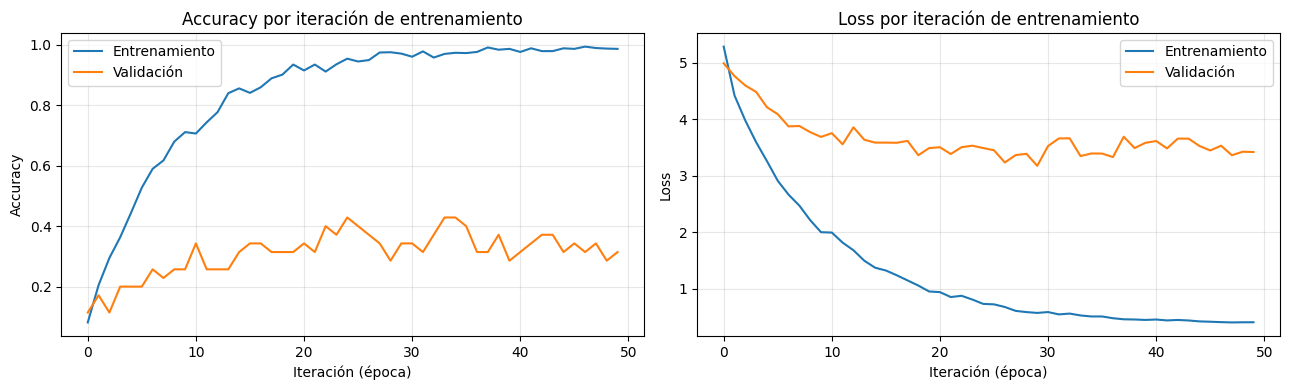

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['accuracy'],     label='Entrenamiento')
axes[0].plot(history.history['val_accuracy'], label='Validación')
axes[0].set_title('Accuracy por iteración de entrenamiento')
axes[0].set_xlabel('Iteración (época)')
axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Entrenamiento')
axes[1].plot(history.history['val_loss'], label='Validación')
axes[1].set_title('Loss por iteración de entrenamiento')
axes[1].set_xlabel('Iteración (época)')
axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Evaluación en conjunto de prueba

In [6]:
df_top35 = pd.read_csv(CSV_TOP35)
idx_map  = {c: i for i, c in enumerate(sorted(df_top35['glosa'].unique()))}

X_all, y_all = [], []
for _, row in df_top35.iterrows():
    npy = os.path.join(KEYPOINTS_DIR, f"{row['video_id']}.npy")
    if not os.path.exists(npy): continue
    kp = np.load(npy)
    if kp.shape != (N_FRAMES, 225): continue
    X_all.append(kp); y_all.append(idx_map.get(row['glosa'], -1))
X_all = np.array(X_all, dtype=np.float32)
y_all = np.array(y_all, dtype=np.int32)

split    = np.load(SPLIT_PATH, allow_pickle=True)
idx_test = split['idx_test'].tolist()

X_ls = np.array([normalizar_hombros(X_all[i]) for i in idx_test], dtype=np.float32)
y_ls = y_all[idx_test]

t0      = time.perf_counter()
prob_ls = model.predict(X_ls, verbose=0)
t1      = time.perf_counter()

pred_ls      = np.argmax(prob_ls, axis=1)
acc_ls       = accuracy_score(y_ls, pred_ls)
ms_por_video = (t1 - t0) / len(X_ls) * 1000

print(f'Accuracy en prueba (Label Studio): {acc_ls*100:.1f}%')
print(f'Tiempo de inferencia: {ms_por_video:.2f} ms/video  ({1000/ms_por_video:.1f} fps)')
print(f'Parámetros entrenables: {model.count_params():,}')

Accuracy en prueba (Label Studio): 48.6%
Tiempo de inferencia: 31.81 ms/video  (31.4 fps)
Parámetros entrenables: 88,195


## 5. Tabla 3.12 — Rendimiento del modelo final

In [ ]:
# Accuracy robusta de la validación cruzada (experimento A/B, Modelo B)
cv_path = os.path.join(DATA_DIR, 'experimentos', 'exp1_ab', 'salidas', 'comparativa_5fold.csv')
df_cv   = pd.read_csv(cv_path)
fila_b  = df_cv[df_cv['modelo'].str.startswith('B')].iloc[0]
acc_cv  = fila_b['acc_media'] * 100
ci_low  = fila_b['ci95_low']  * 100
ci_high = fila_b['ci95_high'] * 100

val_acc_max = max(history.history['val_accuracy'])
epocas      = len(history.history['accuracy'])

sep = "=" * 62
print(sep)
print("  Rendimiento del modelo final")
print(sep)
print(f"  {'Accuracy robusta — 5-Fold CV':<40} {acc_cv:.1f}%  IC95=[{ci_low:.1f}%, {ci_high:.1f}%]")
print(f"  {'Accuracy en prueba (Label Studio)':<40} {acc_ls*100:.1f}%")
print(f"  {'Accuracy máx. de validación (modelo final)':<40} {val_acc_max*100:.1f}%  (iteración {history.history['val_accuracy'].index(val_acc_max)+1})")
print(f"  {'Iteraciones de entrenamiento (épocas)':<40} {epocas}")
print(f"  {'Tiempo de inferencia por video':<40} {ms_por_video:.2f} ms")
print(f"  {'Equivalente en fotogramas por segundo':<40} {1000/ms_por_video:.1f} fps")
print(f"  {'Parámetros entrenables':<40} {model.count_params():,}".replace(",", " "))
print(f"  {'Viable en tiempo real':<40} {'Sí' if ms_por_video < 100 else 'No'}")
print(sep)

## 6. Guardar modelo y métricas

In [ ]:
model.save(os.path.join(SALIDA_DIR, 'mejor_modelo_v2.keras'))
np.save(os.path.join(SALIDA_DIR, 'historial_v2.npy'), history.history)

pd.DataFrame([{
    'ms_por_video':       round(ms_por_video, 2),
    'fps_equivalente':    round(1000 / ms_por_video, 1),
    'viable_tiempo_real': ms_por_video < 100,
    'n_parametros':       model.count_params(),
}]).to_csv(os.path.join(SALIDA_DIR, 'metricas_rendimiento.csv'),
           index=False, encoding='utf-8-sig')

print('Modelo y métricas guardados en:', SALIDA_DIR)